In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-ct/demos/demo2.png
/kaggle/input/brain-ct/demos/demo3.png
/kaggle/input/brain-ct/demos/demo.jpg
/kaggle/input/brain-ct/demos/demo4.png
/kaggle/input/brain-ct/brain_CT_sinograms/56 (32).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/101 (24).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/116 (16).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/56 (2).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/106 (10).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/64 (1).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/96 (1) - Copy - Copy.jpg
/kaggle/input/brain-ct/brain_CT_sinograms/61 (22).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/98 (29) - Copy - Copy.jpg
/kaggle/input/brain-ct/brain_CT_sinograms/55 (32).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/50 (7).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/64 (17).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/126 (28).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/120 (23).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/108 (25).jpg
/kagg

# Loading the Dataset

In [2]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

2025-06-20 17:48:39.469177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750441719.672048      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750441719.733013      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Paths
input_dir = '/kaggle/input/brain-ct/brain_CT_sinograms'
output_dir = '/kaggle/input/brain-ct/brain_CT'

# Get sorted file names (to ensure matching)
input_files = sorted(os.listdir(input_dir))
output_files = sorted(os.listdir(output_dir))

In [4]:
# Initialize lists
x_data = []
y_data = []

# Load images
for in_file, out_file in zip(input_files, output_files):
    # Load grayscale image and resize to (256, 256)
    input_img = load_img(os.path.join(input_dir, in_file), color_mode='grayscale', target_size=(256, 256))
    output_img = load_img(os.path.join(output_dir, out_file), color_mode='grayscale', target_size=(256, 256))
    
    # Convert to array and normalize to [0, 1]
    x = img_to_array(input_img) / 255.0
    y = img_to_array(output_img) / 255.0

    x_data.append(x)
    y_data.append(y)

# Convert to NumPy arrays
x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)

print("Input shape:", x_data.shape)   # (125, 256, 256, 1)
print("Output shape:", y_data.shape)  # (125, 256, 256, 1)

Input shape: (125, 256, 256, 1)
Output shape: (125, 256, 256, 1)


In [5]:
x_train = x_data[:100]
x_test = x_data[100:]
y_train = y_data[:100]
y_test = y_data[100:]

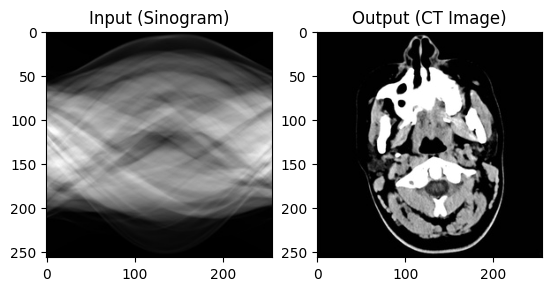

In [6]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(x_data[0].squeeze(), cmap='gray')
plt.title('Input (Sinogram)')

plt.subplot(1, 2, 2)
plt.imshow(y_data[0].squeeze(), cmap='gray')
plt.title('Output (CT Image)')
plt.show()

# LOSS

In [7]:
from tensorflow.keras import layers, models

# ----- Custom Loss: MSE + SSIM -----
def mse_ssim_loss(y_true, y_pred, ssim_weight=0.1):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
    ssim_loss = tf.reduce_mean(1.0 - ssim)
    return mse + ssim_weight * ssim_loss

# Model

In [8]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # ----- Encoder -----
    c1 = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    c1 = layers.LeakyReLU(alpha=0.1)(c1)
    c1 = layers.Conv2D(64, (3, 3), padding='same')(c1)
    c1 = layers.LeakyReLU(alpha=0.1)(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), padding='same')(p1)
    c2 = layers.LeakyReLU(alpha=0.1)(c2)
    c2 = layers.Conv2D(128, (3, 3), padding='same')(c2)
    c2 = layers.LeakyReLU(alpha=0.1)(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), padding='same')(p2)
    c3 = layers.LeakyReLU(alpha=0.1)(c3)
    c3 = layers.Conv2D(256, (3, 3), padding='same')(c3)
    c3 = layers.LeakyReLU(alpha=0.1)(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), padding='same')(p3)
    c4 = layers.LeakyReLU(alpha=0.1)(c4)
    c4 = layers.Conv2D(512, (3, 3), padding='same')(c4)
    c4 = layers.LeakyReLU(alpha=0.1)(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # ----- Bottleneck -----
    c5 = layers.Conv2D(1024, (3, 3), padding='same')(p4)
    c5 = layers.LeakyReLU(alpha=0.1)(c5)
    c5 = layers.Conv2D(1024, (3, 3), padding='same')(c5)
    c5 = layers.LeakyReLU(alpha=0.1)(c5)

    # ----- Decoder -----
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), padding='same')(u6)
    c6 = layers.LeakyReLU(alpha=0.1)(c6)
    c6 = layers.Conv2D(512, (3, 3), padding='same')(c6)
    c6 = layers.LeakyReLU(alpha=0.1)(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), padding='same')(u7)
    c7 = layers.LeakyReLU(alpha=0.1)(c7)
    c7 = layers.Conv2D(256, (3, 3), padding='same')(c7)
    c7 = layers.LeakyReLU(alpha=0.1)(c7)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), padding='same')(u8)
    c8 = layers.LeakyReLU(alpha=0.1)(c8)
    c8 = layers.Conv2D(128, (3, 3), padding='same')(c8)
    c8 = layers.LeakyReLU(alpha=0.1)(c8)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), padding='same')(u9)
    c9 = layers.LeakyReLU(alpha=0.1)(c9)
    c9 = layers.Conv2D(64, (3, 3), padding='same')(c9)
    c9 = layers.LeakyReLU(alpha=0.1)(c9)

    outputs = layers.Conv2D(1, (1, 1))(c9)

    model = models.Model(inputs, outputs)
    return model


In [9]:
model = build_unet(input_shape=(256, 256, 1))
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
model.summary()

I0000 00:00:1750441735.827751      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750441735.828414      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 256, 256, 64)   │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 256, 256, 64)   │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ leaky_re_lu_1[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 128, 128, 128)  │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ leaky_re_lu_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 128, 128, 128)  │              0 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ leaky_re_lu_3[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU) │ (None, 64, 64, 256)    │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 256)    │        590,080 │ leaky_re_lu_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU) │ (None, 64, 64, 256)    │              0 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 32, 32, 256)    │              0 │ leaky_re_lu_5[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU) │ (None, 32, 32, 512)    │              0 │ conv2d_6[0][0]         │
├──────────────────────

 Total params: 31,377,793 (119.70 MB)

 Trainable params: 31,377,793 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("Weights before:", model.get_weights()[0].mean())

Weights before: 0.00129954


In [11]:
# ----- Train the Model -----
model.fit(x_data, y_data, epochs=30, batch_size=8, validation_split=0.1)

Epoch 1/30


I0000 00:00:1750441745.931451      66 service.cc:148] XLA service 0x7e4458002790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750441745.932445      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750441745.932468      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750441746.657607      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-20 17:49:11.185404: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[8,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_s

14/14 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 4.7998 - mse: 4.7998 - val_loss: 83.6807 - val_mse: 83.6807
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 485ms/step - loss: 272.5432 - mse: 272.5432 - val_loss: 518.9599 - val_mse: 518.9599
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 486ms/step - loss: 1422.7802 - mse: 1422.7802 - val_loss: 1.9704 - val_mse: 1.9704
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 489ms/step - loss: 958162.0000 - mse: 958162.1250 - val_loss: 818585344.0000 - val_mse: 818585280.0000
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 490ms/step - loss: 14092597198848.0000 - mse: 14092595101696.0000 - val_loss: 75512008.0000 - val_mse: 75512008.0000
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 497ms/step - loss: 713093376.0000 - mse: 713093248.0000 - val_loss: 61743544.0000 - val_mse: 61743536.0000
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 503ms/step - loss: 75743528.0000 - mse: 75743528.0000 - val_loss: 1058363.2500 - val_mse: 1058363.2500
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 506ms/st

In [12]:
print("Weights after:", model.get_weights()[0].mean())

Weights after: -0.0004158473


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.activations import sigmoid

def predict_and_plot(model, x_data, y_data, index=0):
    # Select one sample
    input_img = x_data[index]         # shape: (256, 256, 1)
    ground_truth = y_data[index]      # shape: (256, 256, 1)


    input_img_batch = np.expand_dims(input_img, axis=0)  # shape: (1, 256, 256, 1)
    prediction = model.predict(input_img_batch)[0]       # get rid of batch dim
    print("here", prediction.min(), prediction.max(), prediction.mean())

    # Remove last channel dimension for plotting
    input_img_plot = input_img[:, :, 0]
    prediction_plot = prediction[:, :, 0]
    ground_truth_plot = ground_truth[:, :, 0]

    # Plot all
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(input_img_plot, cmap='gray')
    plt.title('Input')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(prediction_plot, cmap='gray')
    plt.title('Predicted Output')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth_plot, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


def predict_and_plot_with_sigmoid(model, x_data, y_data, index=0):
    # Select image
    input_img = x_data[index]  # shape: (256, 256, 1)
    ground_truth = y_data[index]

    # Add batch dimension: (1, 256, 256, 1)
    input_batch = np.expand_dims(input_img, axis=0)

    # Predict
    prediction_raw = model.predict(input_batch)[0]  # shape: (256, 256, 1)
    
    # Apply sigmoid manually
    prediction_sigmoid = sigmoid(prediction_raw).numpy()
    print(prediction_sigmoid.min(), prediction_sigmoid.max(), prediction_sigmoid.mean())
    # Squeeze channels for display
    input_img = input_img[:, :, 0]
    prediction_sigmoid = prediction_sigmoid[:, :, 0]
    ground_truth = ground_truth[:, :, 0]

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(input_img, cmap='gray')
    plt.title('Input')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(prediction_sigmoid, cmap='gray')
    plt.title('Prediction (Sigmoid)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
0.0 1.0 0.52175593


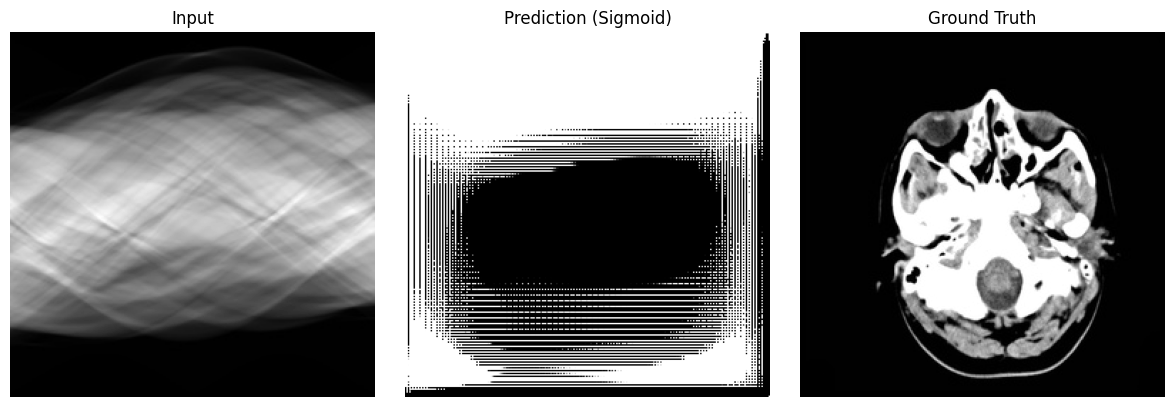

In [14]:
predict_and_plot_with_sigmoid(model, x_data, y_data, index=50)  # change index to test different images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
here -2787.4473 2034.9232 44.83606


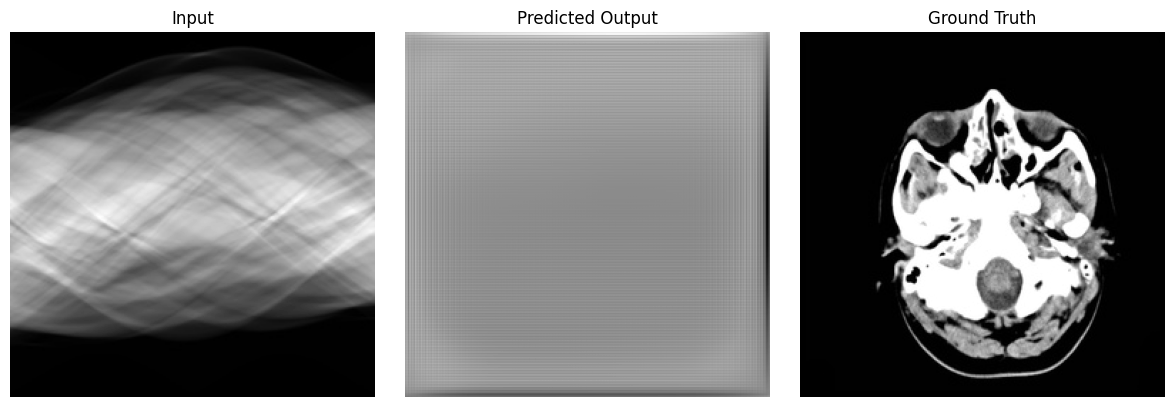

In [15]:
predict_and_plot(model, x_data, y_data, index = 50)

In [16]:
print("y_data[0] stats:", y_data[0].min(), y_data[0].max(), y_data[0].mean())


y_data[0] stats: 0.0 1.0 0.20945853
